# 🛒 E-commerce Product Recommendation System
## Notebook 1: EDA & Data Cleaning

**Dataset:** UCI Online Retail (Dec 2010 – Dec 2011)  
**Goal:** Build a personalised recommendation system — given a customer's purchase history, predict what they'll buy next.  
**Framing:** Binary classification on (CustomerID, Product) pairs → rank by purchase probability → top-K recommendations

---
### Notebook Outline
1. Load Data
2. Initial EDA — shape, nulls, dtypes
3. Visualisations
4. Data Cleaning — step by step with reasoning
5. Summary of all decisions

---
## 1. Load Data

In [1]:
import ssl
import urllib.request

# Patch all three SSL paths — needed because Homebrew Python on macOS
# doesn't trust the UCI server's certificate chain.
# Safe for a local notebook fetching a public dataset.

# Path 1: used by urllib.request.urlopen() without an explicit context (e.g. pd.read_csv(url))
ssl._create_default_https_context = ssl._create_unverified_context

# Path 2: used by ucimlrepo's explicit ssl.create_default_context(cafile=...) call
def _unverified_context(*args, **kwargs):
    ctx = ssl.SSLContext(ssl.PROTOCOL_TLS_CLIENT)
    ctx.check_hostname = False
    ctx.verify_mode = ssl.CERT_NONE
    return ctx

ssl.create_default_context = _unverified_context

# Path 3: install a global opener so any urllib call through build_opener also skips verification
_ctx = ssl.SSLContext(ssl.PROTOCOL_TLS_CLIENT)
_ctx.check_hostname = False
_ctx.verify_mode = ssl.CERT_NONE
urllib.request.install_opener(
    urllib.request.build_opener(urllib.request.HTTPSHandler(context=_ctx))
)

from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

online_retail = fetch_ucirepo(id=352)
df = online_retail.data.features.copy()

print("✅ Data loaded successfully")
df.head()

✅ Data loaded successfully


,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


---
## 2. Initial EDA

Before any cleaning, we inspect:
- **Shape** — how many rows and columns?
- **Null values** — which columns have missing data and how much?
- **Dtypes** — are columns the right type for downstream processing?

⚠️ Two columns are critical for our model:
- `CustomerID` — user identifier. Null = can't personalise → must handle carefully
- `Description` — product identifier (surrogate for StockCode). Needs normalisation.

In [2]:
print("Shape:", df.shape)
print("\nNull values:")
print(df.isnull().sum())
print("\nDtypes:")
print(df.dtypes)
print("\nSample data:")
df.describe()

Shape: (541909, 6)

Null values:
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Dtypes:
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

Sample data:


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


---
## 3. Visualisations

Three plots before cleaning:
1. **Missing values** — visualise which columns have nulls and how many
2. **Purchase distribution** — how many transactions per customer? (identify skew + outliers)
3. **Quantity distribution** — are there suspicious negative values (returns/cancellations)?

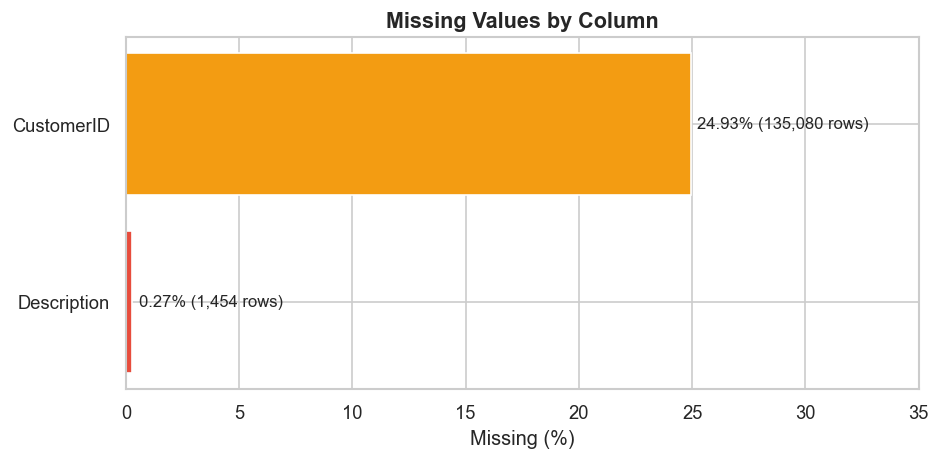


⚠️  CustomerID: 135,080 nulls (24.93% of data)
→ These rows cannot be used for personalised recommendations
→ BUT we keep them separately for popularity-based fallback (cold start users)


In [3]:
# ── Plot 1: Missing Values ─────────────────────────────────────────────
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
null_df = pd.DataFrame({'Count': null_counts, 'Percentage': null_pct})
null_df = null_df[null_df['Count'] > 0]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(null_df.index, null_df['Percentage'], color=['#E74C3C', '#F39C12'])
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values by Column', fontweight='bold', fontsize=13)
for bar, (_, row) in zip(bars, null_df.iterrows()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{row['Percentage']}% ({int(row['Count']):,} rows)",
            va='center', fontsize=10)
ax.set_xlim(0, 35)
plt.tight_layout()
plt.savefig('../graphs/missing_values.png', bbox_inches='tight')
plt.show()

print(f"\n⚠️  CustomerID: {null_df.loc['CustomerID', 'Count']:,} nulls ({null_df.loc['CustomerID', 'Percentage']}% of data)")
print("→ These rows cannot be used for personalised recommendations")
print("→ BUT we keep them separately for popularity-based fallback (cold start users)")

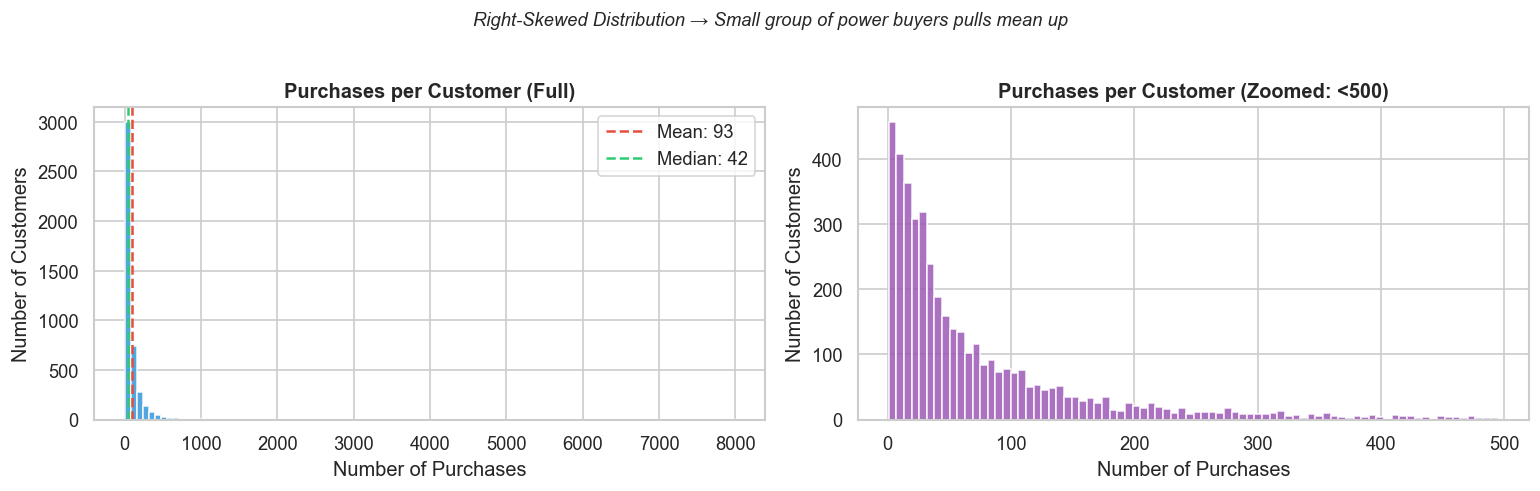

Mean purchases/customer:   93.1
Median purchases/customer: 42.0
Max purchases/customer:    7,983

→ Mean >> Median = right-skewed = power buyers / wholesale resellers exist


In [4]:
# ── Plot 2: Purchase Distribution per Customer ─────────────────────────
# Only non-null CustomerIDs
df_known = df[df['CustomerID'].notna()].copy()
purchase_counts = df_known.groupby('CustomerID')['Description'].count()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: full distribution (right-skewed)
axes[0].hist(purchase_counts, bins=100, color='#3498DB', edgecolor='white', alpha=0.85)
axes[0].axvline(purchase_counts.mean(), color='#E74C3C', linestyle='--', label=f'Mean: {purchase_counts.mean():.0f}')
axes[0].axvline(purchase_counts.median(), color='#2ECC71', linestyle='--', label=f'Median: {purchase_counts.median():.0f}')
axes[0].set_title('Purchases per Customer (Full)', fontweight='bold')
axes[0].set_xlabel('Number of Purchases')
axes[0].set_ylabel('Number of Customers')
axes[0].legend()

# Right: zoomed in (< 500 purchases) — shows typical customer
axes[1].hist(purchase_counts[purchase_counts < 500], bins=80, color='#9B59B6', edgecolor='white', alpha=0.85)
axes[1].set_title('Purchases per Customer (Zoomed: <500)', fontweight='bold')
axes[1].set_xlabel('Number of Purchases')
axes[1].set_ylabel('Number of Customers')

plt.suptitle('Right-Skewed Distribution → Small group of power buyers pulls mean up',
             fontsize=11, fontstyle='italic', y=1.02)
plt.tight_layout()
plt.savefig('../graphs/purchase_distribution.png', bbox_inches='tight')
plt.show()

print(f"Mean purchases/customer:   {purchase_counts.mean():.1f}")
print(f"Median purchases/customer: {purchase_counts.median():.1f}")
print(f"Max purchases/customer:    {purchase_counts.max():,}")
print("\n→ Mean >> Median = right-skewed = power buyers / wholesale resellers exist")

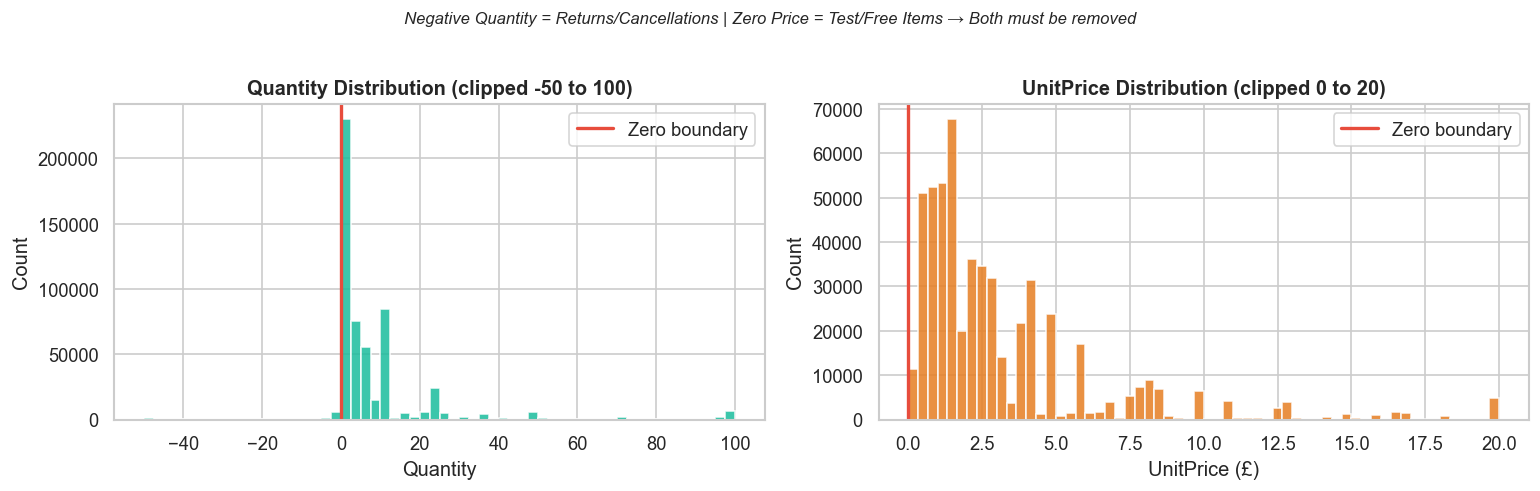

Rows with Quantity ≤ 0 (returns/cancellations): 10,624
Rows with UnitPrice ≤ 0 (free/test items):      2,517


In [5]:
# ── Plot 3: Quantity Distribution — spotting returns ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: Quantity histogram
clipped = df['Quantity'].clip(-50, 100)
axes[0].hist(clipped, bins=60, color='#1ABC9C', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='#E74C3C', linewidth=2, label='Zero boundary')
axes[0].set_title('Quantity Distribution (clipped -50 to 100)', fontweight='bold')
axes[0].set_xlabel('Quantity')
axes[0].set_ylabel('Count')
axes[0].legend()

# Right: UnitPrice histogram
clipped_price = df['UnitPrice'].clip(0, 20)
axes[1].hist(clipped_price, bins=60, color='#E67E22', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='#E74C3C', linewidth=2, label='Zero boundary')
axes[1].set_title('UnitPrice Distribution (clipped 0 to 20)', fontweight='bold')
axes[1].set_xlabel('UnitPrice (£)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Negative Quantity = Returns/Cancellations | Zero Price = Test/Free Items → Both must be removed',
             fontsize=10, fontstyle='italic', y=1.02)
plt.tight_layout()
plt.savefig('../graphs/quantity_price_distribution.png', bbox_inches='tight')
plt.show()

returns = (df['Quantity'] <= 0).sum()
free_items = (df['UnitPrice'] <= 0).sum()
print(f"Rows with Quantity ≤ 0 (returns/cancellations): {returns:,}")
print(f"Rows with UnitPrice ≤ 0 (free/test items):      {free_items:,}")

---
## 4. Data Cleaning

Each cleaning step below has an explicit reason. In production, every data decision must be documented and justified — this is what separates a deployable pipeline from a notebook experiment.

### Cleaning Steps:
| Step | Action | Reason |
|------|--------|--------|
| 1 | Save anonymous rows | CustomerID nulls → popularity fallback for cold start users |
| 2 | Drop CustomerID nulls | Can't build personalised recommendations without user identity |
| 3 | Fix CustomerID dtype | Float → Int → String. Avoids `13085.0` string mismatches |
| 4 | Parse InvoiceDate | String → datetime. Enables temporal feature extraction |
| 5 | Extract temporal features | Month, day of week, hour — seasonal purchase patterns |
| 6 | Normalise Description | Strip whitespace + uppercase. Prevents duplicate product entries |
| 7 | Remove returns | Quantity ≤ 0 → customer returned item — opposite of purchase signal |
| 8 | Remove free/test items | UnitPrice ≤ 0 → internal transfers, test entries, not real purchases |
| 9 | Remove cold start users | < 5 purchases → insufficient history for personalised model |
| 10 | Remove wholesale customers | > 349 purchases (3×IQR) → bulk resellers, not gift shoppers |

In [6]:
# ── Step 1 & 2: Handle CustomerID nulls ───────────────────────────────
# Save anonymous rows — useful for computing product popularity (cold start fallback)
# These rows tell us WHICH products sell well globally, even without user identity
df_anonymous = df[df['CustomerID'].isna()].copy()

# Keep only rows with known customers for personalised model
df = df[df['CustomerID'].notna()].copy()

print(f"Anonymous rows saved for popularity fallback: {len(df_anonymous):,}")
print(f"Rows with known CustomerID: {len(df):,}")

Anonymous rows saved for popularity fallback: 135,080
Rows with known CustomerID: 406,829


In [7]:
# ── Steps 3–6: Fix dtypes + extract features + normalise Description ──

# CustomerID: float → int → string
# Must go via int first — direct float→str gives '13085.0' instead of '13085'
df['CustomerID'] = df['CustomerID'].astype(int).astype(str)

# InvoiceDate: string → datetime
# Enables .dt accessor for temporal features
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Extract temporal features — gift store has strong seasonality
df['month']       = df['InvoiceDate'].dt.month       # Christmas spike in Nov/Dec
df['day_of_week'] = df['InvoiceDate'].dt.dayofweek   # 0=Monday, 6=Sunday
df['hour']        = df['InvoiceDate'].dt.hour        # Business hours vs personal shopping

# Normalise Description — used as product identifier since StockCode is unavailable
# strip() removes leading/trailing whitespace → same product, different spacing = one product
# upper() normalises case → 'lantern' and 'LANTERN' are the same product
df['Description'] = df['Description'].str.strip().str.upper()

print("✅ Dtypes fixed, temporal features extracted, Description normalised")
print(df.dtypes)

✅ Dtypes fixed, temporal features extracted, Description normalised
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID                str
Country                   str
month                   int32
day_of_week             int32
hour                    int32
dtype: object


In [8]:
# ── Steps 7 & 8: Remove returns and free/test items ───────────────────
before = len(df)

# Quantity ≤ 0 → return or cancellation
# Keeping these would tell model 'customer bought this' when they actually RETURNED it
df = df[df['Quantity'] > 0]

# UnitPrice ≤ 0 → free samples, internal transfers, test entries
# These are not real purchase decisions — corrupt purchase signal
df = df[df['UnitPrice'] > 0]

after = len(df)
print(f"Rows removed (returns + free items): {before - after:,}")
print(f"Rows remaining: {after:,}")

Rows removed (returns + free items): 8,945
Rows remaining: 397,884


In [9]:
# ── Step 9: Remove cold start users (< 5 purchases) ───────────────────
# Cold start problem: customers with < 5 purchases have insufficient history
# to build a meaningful preference profile.
# These customers → fallback to popularity-based recommendations instead
customer_purchase_counts = df.groupby('CustomerID')['Description'].count()
active_customers = customer_purchase_counts[customer_purchase_counts >= 5].index

cold_start_count = df['CustomerID'].nunique() - len(active_customers)
print(f"Cold start users removed (< 5 purchases): {cold_start_count}")
print(f"Active customers retained: {len(active_customers)}")

Cold start users removed (< 5 purchases): 227
Active customers retained: 4111


In [10]:
# ── Step 10: Remove wholesale customers (outliers) ────────────────────
# Using 3×IQR (not standard 1.5×IQR) because:
# This is a GIFT store — high volume buyers around holidays are legitimate customers
# 3×IQR only removes extreme reseller-level outliers (bulk same-item orders)
# whose purchase patterns would corrupt RFM features for regular customers

Q1 = customer_purchase_counts.quantile(0.25)   # 17
Q3 = customer_purchase_counts.quantile(0.75)   # 100
IQR = Q3 - Q1                                  # 83
upper_bound = Q3 + 3 * IQR                     # 349

wholesale_customers = customer_purchase_counts[customer_purchase_counts > upper_bound].index

print(f"IQR bounds → Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Upper bound (3×IQR): {upper_bound} purchases/year")
print(f"Wholesale customers removed: {len(wholesale_customers)}")

# Apply both filters
df = df[df['CustomerID'].isin(active_customers)]
df = df[~df['CustomerID'].isin(wholesale_customers)]

print(f"\nFinal dataset shape: {df.shape}")

IQR bounds → Q1: 17.0, Q3: 100.0, IQR: 83.0
Upper bound (3×IQR): 349.0 purchases/year
Wholesale customers removed: 175

Final dataset shape: (270848, 9)


In [11]:
# ── Bonus: Build Popularity List (for cold start fallback) ────────────
# Using df_anonymous (no CustomerID) + df together to compute global product popularity
# This list will be used in production to recommend products to new/cold start users

# Combine anonymous + known transactions for popularity signal
all_transactions = pd.concat([
    df[['Description', 'Quantity']],
    df_anonymous[df_anonymous['Quantity'] > 0][['Description', 'Quantity']]
])
all_transactions['Description'] = all_transactions['Description'].str.strip().str.upper()

popularity = (all_transactions
              .groupby('Description')['Quantity']
              .sum()
              .sort_values(ascending=False)
              .reset_index())
popularity.columns = ['Description', 'TotalUnitsSold']

print("Top 10 most popular products globally:")
print(popularity.head(10).to_string(index=False))

Top 10 most popular products globally:
                       Description  TotalUnitsSold
 WORLD WAR 2 GLIDERS ASSTD DESIGNS           46870
           JUMBO BAG RED RETROSPOT           35703
WHITE HANGING HEART T-LIGHT HOLDER           29985
                    POPCORN HOLDER           29380
     ASSORTED COLOUR BIRD ORNAMENT           28140
         PACK OF 12 LONDON TISSUES           24674
   PACK OF 72 RETROSPOT CAKE CASES           24292
                RABBIT NIGHT LIGHT           20905
PACK OF 60 PINK PAISLEY CAKE CASES           20636
   VICTORIAN GLASS HANGING T-LIGHT           19629


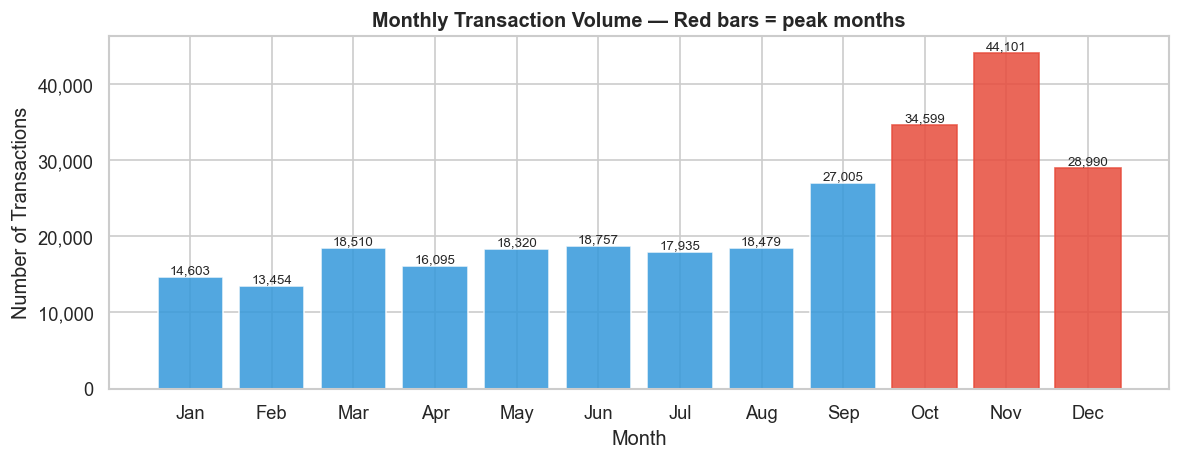

→ Strong Nov/Oct spike = Christmas gifting season
→ This seasonal pattern will be captured in our 'month' feature


In [12]:
# ── Final Visualisation: Monthly transaction volume ────────────────────
monthly = df.groupby('month').size().reset_index(name='transactions')
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly['month_name'] = monthly['month'].apply(lambda x: month_names[x-1])

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(monthly['month_name'], monthly['transactions'],
              color='#3498DB', edgecolor='white', alpha=0.85)

# Highlight peak months
for i, (bar, val) in enumerate(zip(bars, monthly['transactions'])):
    if val > monthly['transactions'].quantile(0.75):
        bar.set_color('#E74C3C')
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,}', ha='center', va='bottom', fontsize=8)

ax.set_title('Monthly Transaction Volume — Red bars = peak months', fontweight='bold', fontsize=12)
ax.set_xlabel('Month')
ax.set_ylabel('Number of Transactions')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('../graphs/monthly_transactions.png', bbox_inches='tight')
plt.show()

print("→ Strong Nov/Oct spike = Christmas gifting season")
print("→ This seasonal pattern will be captured in our 'month' feature")

---
## 5. Cleaning Summary

In [13]:
# ── Final Verification ─────────────────────────────────────────────────
print("=" * 55)
print("        CLEANING PIPELINE — FINAL SUMMARY")
print("=" * 55)
print(f"  Original rows:          541,909")
print(f"  Final rows:             {len(df):,}")
print(f"  Rows removed:           {541909 - len(df):,} ({(541909 - len(df))/541909*100:.1f}%)")
print("-" * 55)
print(f"  Unique customers:       {df['CustomerID'].nunique():,}")
print(f"  Unique products:        {df['Description'].nunique():,}")
print(f"  Date range:             {df['InvoiceDate'].min().date()} → {df['InvoiceDate'].max().date()}")
print("-" * 55)
print(f"  Sparsity of user-item matrix:")
total_pairs = df['CustomerID'].nunique() * df['Description'].nunique()
actual_pairs = df.groupby(['CustomerID', 'Description']).ngroups
sparsity = (1 - actual_pairs / total_pairs) * 100
print(f"    Total possible pairs:  {total_pairs:,}")
print(f"    Actual purchases:      {actual_pairs:,}")
print(f"    Sparsity:              {sparsity:.1f}%")
print("=" * 55)
print()
print("  Decisions Made:")
print("  [1] Anonymous rows → saved to df_anonymous (popularity fallback)")
print("  [2] CustomerID nulls dropped → can't personalise")
print("  [3] CustomerID: float → int → str (avoids '13085.0' mismatches)")
print("  [4] InvoiceDate → datetime (enables temporal features)")
print("  [5] Description normalised → strip + upper (deduplication)")
print("  [6] Quantity ≤ 0 dropped → returns corrupt purchase signal")
print("  [7] UnitPrice ≤ 0 dropped → free/test items not real purchases")
print("  [8] Cold start users removed → < 5 purchases, use popularity fallback")
print("  [9] Wholesale customers removed → > 349 purchases (3×IQR)")
print("       Used 3×IQR not 1.5×IQR — gift store has legitimate bulk buyers")
print("="*55)
print()
print("  Outputs for next notebooks:")
print("  → df              : clean personalised model dataset")
print("  → df_anonymous    : anonymous transactions for popularity")
print("  → popularity      : ranked product list for cold start")
print("  → active_customers: validated customer list")
print("="*55)

        CLEANING PIPELINE — FINAL SUMMARY
  Original rows:          541,909
  Final rows:             270,848
  Rows removed:           271,061 (50.0%)
-------------------------------------------------------
  Unique customers:       3,936
  Unique products:        3,779
  Date range:             2010-12-01 → 2011-12-09
-------------------------------------------------------
  Sparsity of user-item matrix:
    Total possible pairs:  14,874,144
    Actual purchases:      209,137
    Sparsity:              98.6%

  Decisions Made:
  [1] Anonymous rows → saved to df_anonymous (popularity fallback)
  [2] CustomerID nulls dropped → can't personalise
  [3] CustomerID: float → int → str (avoids '13085.0' mismatches)
  [4] InvoiceDate → datetime (enables temporal features)
  [5] Description normalised → strip + upper (deduplication)
  [6] Quantity ≤ 0 dropped → returns corrupt purchase signal
  [7] UnitPrice ≤ 0 dropped → free/test items not real purchases
  [8] Cold start users removed → < 5 

In [14]:
# ── Save cleaned data for next notebooks ──────────────────────────────
df.to_csv('../data/df_clean.csv', index=False)
df_anonymous.to_csv('../data/df_anonymous.csv', index=False)
popularity.to_csv('../data/popularity.csv', index=False)

print("✅ Saved:")
print("   data/df_clean.csv      → main dataset for feature engineering")
print("   data/df_anonymous.csv  → anonymous transactions")
print("   data/popularity.csv    → global product popularity ranking")

✅ Saved:
   data/df_clean.csv      → main dataset for feature engineering
   data/df_anonymous.csv  → anonymous transactions
   data/popularity.csv    → global product popularity ranking
